# Crop Health Monitoring & Disease Detection

End-to-end Kaggle notebook for:
- PlantVillage disease classification
- Indian crop dataset discovery and optional evaluation
- PlantDoc detection support
- EfficientNet-B0 transfer learning
- confidence scores
- accuracy / precision / recall / F1
- confusion matrix
- Grad-CAM explainability
- model saving
- optional YOLO detection and severity estimation


In [1]:
# CELL 1 — GPU and environment

import os
import sys
import random
import warnings
import subprocess
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled. In Kaggle: Settings → Accelerator → GPU.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# CELL 2 — Install dependencies

packages = {
    "timm": "timm",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
    "gradcam": "grad-cam"
}

for module, package in packages.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", package
        ])

print("Dependencies ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.4 MB/s eta 0:00:00
Dependencies ready.


In [3]:
# CELL 3 — Imports and reproducibility

import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [4]:
# CELL 4 — List Kaggle inputs

INPUT_ROOT = "/kaggle/input"

print("Top-level datasets:")
for item in sorted(os.listdir(INPUT_ROOT)):
    print("→", item)

Top-level datasets:
→ datasets


In [5]:
# CELL 5 — Inspect directory structure

for root, dirs, files in os.walk(INPUT_ROOT):
    level = root.replace(INPUT_ROOT, "").count(os.sep)
    if level <= 3:
        print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/andresmgs
/kaggle/input/datasets/andresmgs/plantdec
/kaggle/input/datasets/abdallahalidev
/kaggle/input/datasets/abdallahalidev/plantvillage-dataset
/kaggle/input/datasets/vishesh2395
/kaggle/input/datasets/vishesh2395/crops-disease-dataset


In [6]:
# CELL 6 — Find image files

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG", ".webp", ".WEBP")

all_image_files = []

for root, dirs, files in os.walk(INPUT_ROOT):
    for file in files:
        if file.endswith(IMAGE_EXTENSIONS):
            all_image_files.append(os.path.join(root, file))

print("Total image files found:", len(all_image_files))

for path in all_image_files[:30]:
    print(path)

Total image files found: 329677
/kaggle/input/datasets/andresmgs/plantdec/valid/images/NCLB6_jpg.rf.0200119534bc7ca383dccb23486a52e3.jpg
/kaggle/input/datasets/andresmgs/plantdec/valid/images/Gray_20Leaf_20SpotCORN039_JPG_jpg.rf.a40d81624cd7cc768e72d57541e923b5.jpg
/kaggle/input/datasets/andresmgs/plantdec/valid/images/blueberry_leaf_isolated_white_background_blueberry_leaf_isolated_99227523_jpg.rf.00a825930e9396a34d6c3fc5cf86686e.jpg
/kaggle/input/datasets/andresmgs/plantdec/valid/images/Powdery1_jpg.rf.70fb7a3e9d000734ca5e35ccdb20b385.jpg
/kaggle/input/datasets/andresmgs/plantdec/valid/images/Malus_sylvestris___Crab_Apple_04_jpg.rf.0956fd60c1e804acd9c2f0425193b2b5.jpg
/kaggle/input/datasets/andresmgs/plantdec/valid/images/peppers_bacterial_spot_onpeppertransplant_zoom_jpg.rf.93174c2bf831bee9c02924119aaa0fd5.jpg
/kaggle/input/datasets/andresmgs/plantdec/valid/images/curcurbit_powdery_mildew_erysiphe_or_sphaerotheca_on_cucumber_leaf_B5NP51_jpg.rf.ee37b872042573b392149156086bd6b7.jpg
/k

## 2. Locate PlantVillage

The classifier below expects a folder containing one subfolder per class.

If your Kaggle PlantVillage version has an extra nested folder, the search attempts to locate the folder automatically.

In [7]:
# CELL 7 — Find PlantVillage candidates

plantvillage_candidates = []

for root, dirs, files in os.walk(INPUT_ROOT):
    if "plantvillage" in root.lower():
        plantvillage_candidates.append(root)

print("PlantVillage candidates:")
for p in plantvillage_candidates:
    print("→", p)

if not plantvillage_candidates:
    raise FileNotFoundError(
        "PlantVillage was not found. Add a PlantVillage dataset through Kaggle Add Input."
    )

PlantVillage candidates:
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Tomato___Late_blight
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Tomato___healthy
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Grape___healthy
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Orange___Haunglongbing_(Citrus_greening)
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Soybean___healthy
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Squash___Powdery_mildew
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Potato___healthy
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Corn_(maize)___Northern_Leaf_Blight
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Tomato___Early

In [8]:
# CELL 8 — Select the most useful PlantVillage directory

def score_class_folder(root):
    score = 0
    subdirs = [
        os.path.join(root, d)
        for d in os.listdir(root)
        if os.path.isdir(os.path.join(root, d))
    ]

    for d in subdirs:
        try:
            files = os.listdir(d)
            if any(f.endswith(IMAGE_EXTENSIONS) for f in files):
                score += 1
        except:
            pass

    return score

PLANTVILLAGE_ROOT = max(
    plantvillage_candidates,
    key=score_class_folder
)

print("Selected PlantVillage root:")
print(PLANTVILLAGE_ROOT)
print("Detected class folders:", score_class_folder(PLANTVILLAGE_ROOT))

Selected PlantVillage root:
/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented
Detected class folders: 38


In [9]:
# CELL 9 — Detect PlantVillage class folders

def find_class_dirs(root):
    result = []

    for item in os.listdir(root):
        path = os.path.join(root, item)

        if not os.path.isdir(path):
            continue

        has_images = False

        for subroot, _, files in os.walk(path):
            if any(f.endswith(IMAGE_EXTENSIONS) for f in files):
                has_images = True
                break

        if has_images:
            result.append(path)

    return sorted(result)

class_dirs = find_class_dirs(PLANTVILLAGE_ROOT)

print("Number of detected classes:", len(class_dirs))

for path in class_dirs:
    print("→", os.path.basename(path))

Number of detected classes: 38
→ Apple___Apple_scab
→ Apple___Black_rot
→ Apple___Cedar_apple_rust
→ Apple___healthy
→ Blueberry___healthy
→ Cherry_(including_sour)___Powdery_mildew
→ Cherry_(including_sour)___healthy
→ Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
→ Corn_(maize)___Common_rust_
→ Corn_(maize)___Northern_Leaf_Blight
→ Corn_(maize)___healthy
→ Grape___Black_rot
→ Grape___Esca_(Black_Measles)
→ Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
→ Grape___healthy
→ Orange___Haunglongbing_(Citrus_greening)
→ Peach___Bacterial_spot
→ Peach___healthy
→ Pepper,_bell___Bacterial_spot
→ Pepper,_bell___healthy
→ Potato___Early_blight
→ Potato___Late_blight
→ Potato___healthy
→ Raspberry___healthy
→ Soybean___healthy
→ Squash___Powdery_mildew
→ Strawberry___Leaf_scorch
→ Strawberry___healthy
→ Tomato___Bacterial_spot
→ Tomato___Early_blight
→ Tomato___Late_blight
→ Tomato___Leaf_Mold
→ Tomato___Septoria_leaf_spot
→ Tomato___Spider_mites Two-spotted_spider_mite
→ Tomato___Target_Spot


In [10]:
# CELL 10 — Build PlantVillage dataframe

records = []

for class_dir in class_dirs:
    class_name = os.path.basename(class_dir)

    for root, _, files in os.walk(class_dir):
        for file in files:
            if file.endswith(IMAGE_EXTENSIONS):
                records.append({
                    "image_path": os.path.join(root, file),
                    "class": class_name
                })

df = pd.DataFrame(records)

if df.empty:
    raise RuntimeError("No PlantVillage images were detected.")

class_names = sorted(df["class"].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

df["label"] = df["class"].map(class_to_idx)

print("Images:", len(df))
print("Classes:", len(class_names))
print(df.head())

Images: 54306
Classes: 38
                                          image_path               class  \
0  /kaggle/input/datasets/abdallahalidev/plantvil...  Apple___Apple_scab   
1  /kaggle/input/datasets/abdallahalidev/plantvil...  Apple___Apple_scab   
2  /kaggle/input/datasets/abdallahalidev/plantvil...  Apple___Apple_scab   
3  /kaggle/input/datasets/abdallahalidev/plantvil...  Apple___Apple_scab   
4  /kaggle/input/datasets/abdallahalidev/plantvil...  Apple___Apple_scab   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  


## 3. Dataset exploration

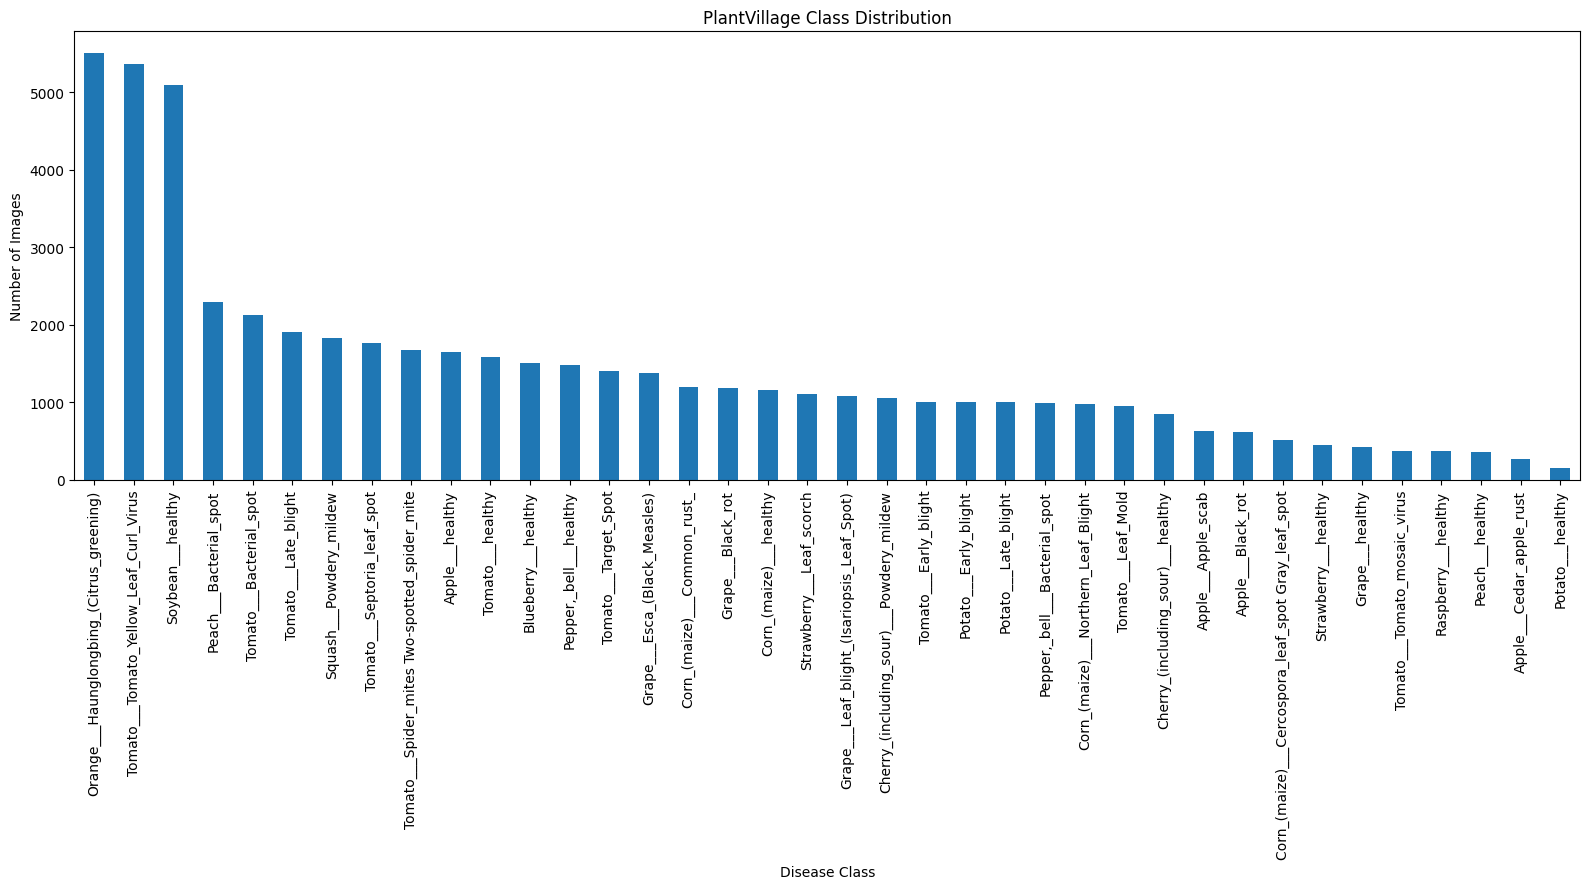

In [11]:
# CELL 11 — Class distribution

class_counts = df["class"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 9))
class_counts.plot(kind="bar")
plt.title("PlantVillage Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

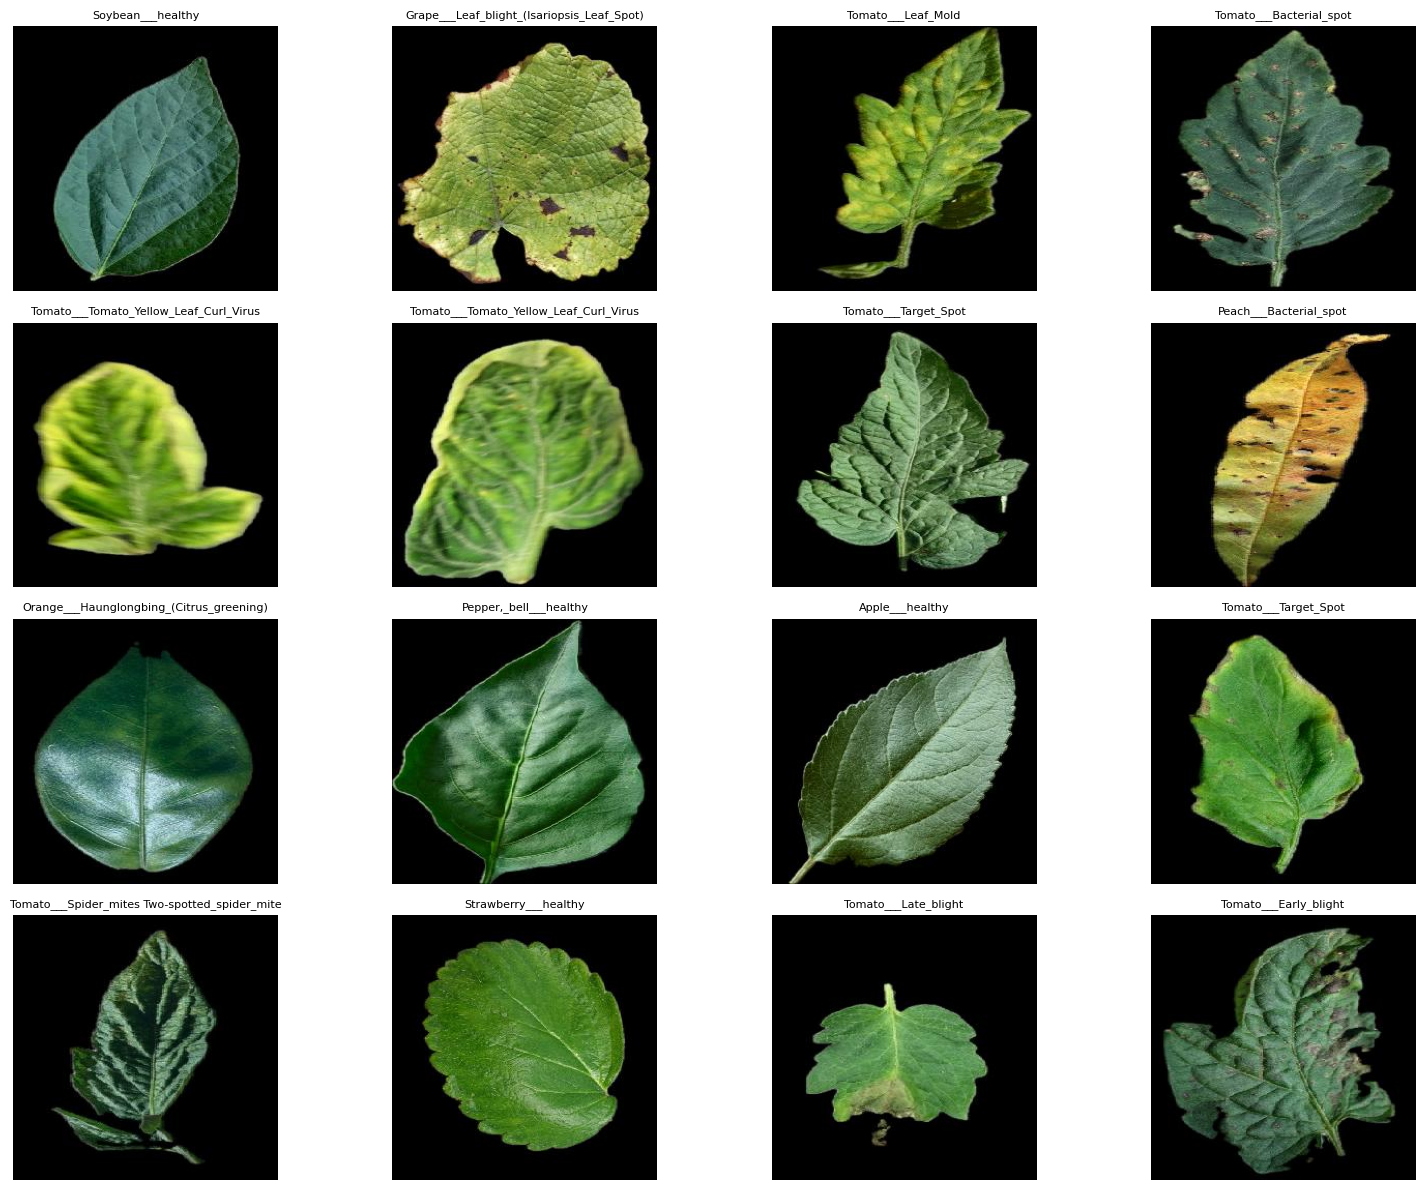

In [12]:
# CELL 12 — Show random samples

n = min(16, len(df))
sample_df = df.sample(n, random_state=SEED)

plt.figure(figsize=(16, 12))

for i, (_, row) in enumerate(sample_df.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(4, 4, i + 1)
    plt.imshow(image)
    plt.title(row["class"], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# CELL 13 — Image size statistics

sizes = []

for path in tqdm(df["image_path"].sample(min(1000, len(df)), random_state=SEED)):
    try:
        with Image.open(path) as img:
            sizes.append(img.size)
    except:
        pass

size_df = pd.DataFrame(sizes, columns=["width", "height"])

print(size_df.describe())

  0%|          | 0/1000 [00:00<?, ?it/s]

        width  height
count  1000.0  1000.0
mean    256.0   256.0
std       0.0     0.0
min     256.0   256.0
25%     256.0   256.0
50%     256.0   256.0
75%     256.0   256.0
max     256.0   256.0


## 4. Train / validation / test split

We use a stratified split:
- 80% train
- 10% validation
- 10% test

In [14]:
# CELL 14 — Stratified split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 43444
Validation: 5431
Test: 5431


## 5. Image preprocessing and augmentation

In [15]:
# CELL 15 — Transforms

IMG_SIZE = 224
BATCH_SIZE = 64

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Transforms ready.")

Transforms ready.


In [16]:
# CELL 16 — Dataset class

class CropDiseaseDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = int(row["label"])

        return image, label

In [17]:
# CELL 17 — Create datasets and loaders

train_dataset = CropDiseaseDataset(
    train_df,
    train_transform
)

val_dataset = CropDiseaseDataset(
    val_df,
    eval_transform
)

test_dataset = CropDiseaseDataset(
    test_df,
    eval_transform
)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": torch.cuda.is_available()
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 679
Validation batches: 85
Test batches: 85


In [18]:
# CELL 18 — Verify a batch

images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([64, 3, 224, 224])
Labels: torch.Size([64])


## 6. EfficientNet-B0 transfer learning

We use ImageNet-pretrained EfficientNet-B0 and replace its final classifier with the number of PlantVillage disease classes.

In [19]:
# CELL 19 — Build model

weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    len(class_names)
)

model = model.to(DEVICE)

print("Number of classes:", len(class_names))
print("Model ready.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 198MB/s]

Number of classes: 38
Model ready.


In [20]:
# CELL 20 — Loss, optimizer and scheduler

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Training configuration ready.")

Training configuration ready.


## 7. Training functions

In [21]:
# CELL 21 — Training function

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return running_loss / total, correct / total

In [22]:
# CELL 22 — Evaluation function

def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        progress = tqdm(loader, desc="Evaluating", leave=False)

        for images, labels in progress:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    return (
        running_loss / total,
        correct / total,
        np.array(all_labels),
        np.array(all_predictions)
    )

## 8. Train

The default is 10 epochs. Increase it if validation performance is still improving.

The best validation model is saved automatically.

In [23]:
# CELL 23 — Train model

EPOCHS = 10
PATIENCE = 4

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_accuracy = 0.0
epochs_without_improvement = 0

BEST_MODEL_PATH = "/kaggle/working/best_crop_health_efficientnet.pth"

for epoch in range(EPOCHS):

    print(f"\n========== Epoch {epoch + 1}/{EPOCHS} ==========")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Train loss:       {train_loss:.4f}")
    print(f"Train accuracy:   {train_acc:.4f}")
    print(f"Validation loss:  {val_loss:.4f}")
    print(f"Validation acc:   {val_acc:.4f}")
    print(f"Learning rate:    {current_lr:.2e}")

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        epochs_without_improvement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "class_to_idx": class_to_idx,
            "img_size": IMG_SIZE
        }, BEST_MODEL_PATH)

        print("✓ Best model saved.")

    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print("Early stopping.")
            break

print("\nBest validation accuracy:", best_val_accuracy)


========== Epoch 1/10 ==========


Training:   0%|          | 0/679 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/85 [00:00<?, ?it/s]

Train loss:       0.5588
Train accuracy:   0.8728
Validation loss:  0.0635
Validation acc:   0.9816
Learning rate:    1.00e-04
✓ Best model saved.

========== Epoch 2/10 ==========


Training:   0%|          | 0/679 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/85 [00:00<?, ?it/s]

Train loss:       0.0139
Train accuracy:   0.9957
Validation loss:  0.0139
Validation acc:   0.9959
Learning rate:    1.00e-04
✓ Best model saved.

========== Epoch 10/10 ==========


Training:   0%|          | 0/679 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/85 [00:00<?, ?it/s]

Train loss:       0.0125
Train accuracy:   0.9963
Validation loss:  0.0169
Validation acc:   0.9954
Learning rate:    1.00e-04

Best validation accuracy: 0.9959491806297183


## 9. Training curves

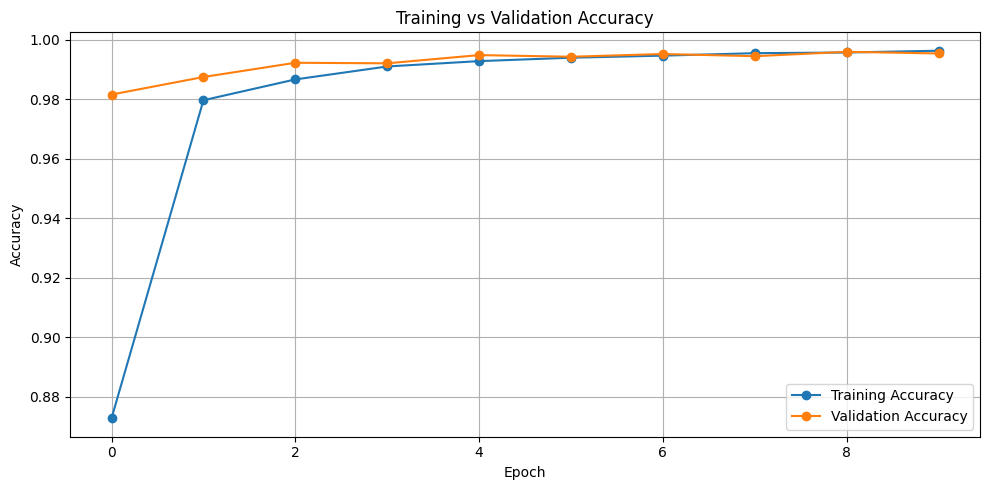

In [24]:
# CELL 24 — Accuracy curve

plt.figure(figsize=(10, 5))

plt.plot(
    history["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

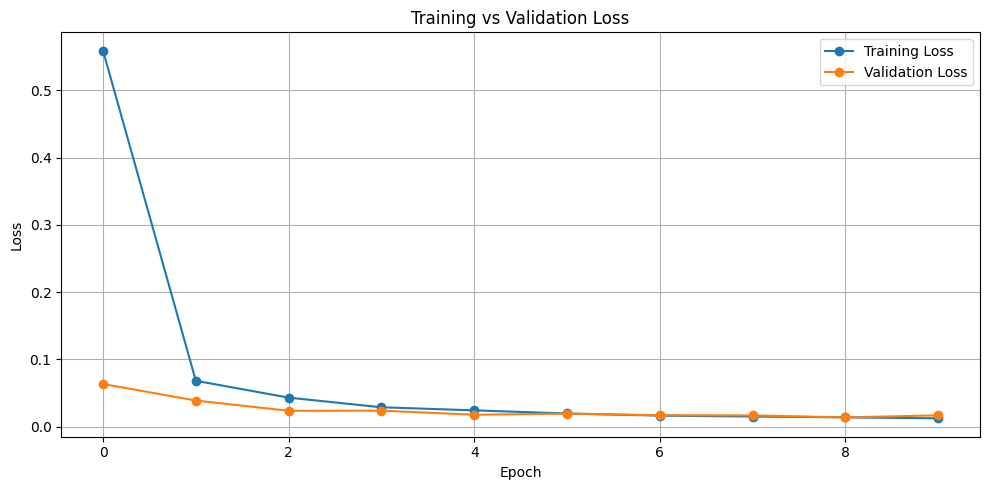

In [25]:
# CELL 25 — Loss curve

plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Test evaluation

In [26]:
# CELL 26 — Load best model

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

print("Best model loaded.")

Best model loaded.


In [27]:
# CELL 27 — Test metrics

test_loss, test_accuracy, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Test Loss:       {test_loss:.4f}")
print(f"Test Accuracy:   {test_accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1:        {f1:.4f}")

Evaluating:   0%|          | 0/85 [00:00<?, ?it/s]

Test Loss:       0.0150
Test Accuracy:   0.9954
Weighted Precision: 0.9955
Weighted Recall:    0.9954
Weighted F1:        0.9954


In [28]:
# CELL 28 — Classification report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9841    0.9920        63
                                 Apple___Black_rot     0.9841    1.0000    0.9920        62
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        27
                                   Apple___healthy     0.9939    1.0000    0.9970       164
                               Blueberry___healthy     1.0000    1.0000    1.0000       150
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       105
                 Cherry_(including_sour)___healthy     1.0000    0.9884    0.9942        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9375    0.8824    0.9091        51
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       119
               Corn_(maize)___Northern_Leaf_Blight     0.9412    0.9697    0.95

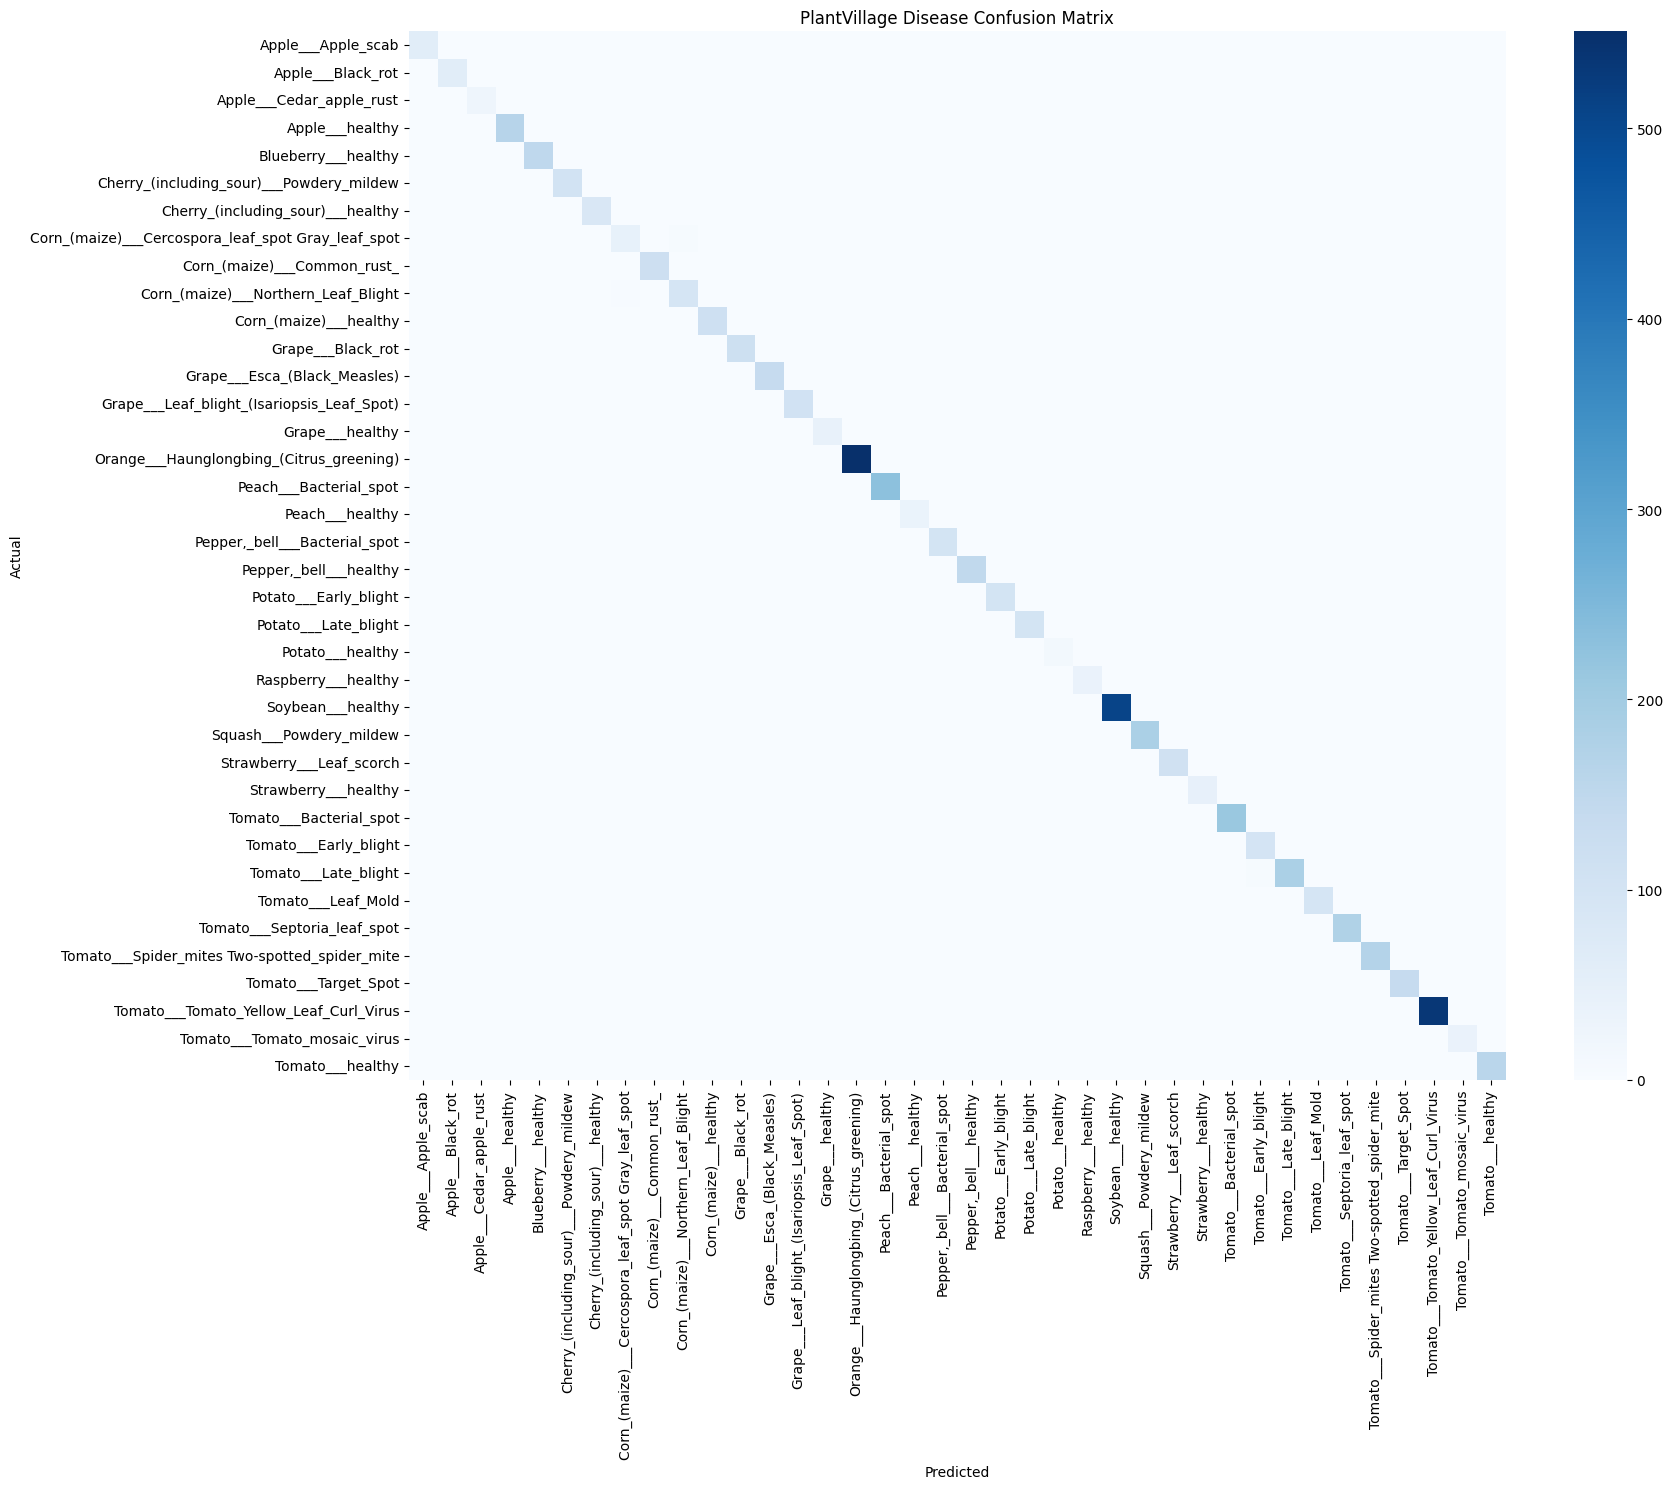

In [29]:
# CELL 29 — Confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PlantVillage Disease Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [30]:
# CELL 30 — Per-class F1 scores

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class = pd.DataFrame(report_dict).T

per_class = per_class.loc[
    class_names,
    ["precision", "recall", "f1-score", "support"]
]

per_class.sort_values(
    "f1-score"
)

,precision,recall,f1-score,support
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.937500,0.882353,0.909091,51.0
Corn_(maize)___Northern_Leaf_Blight,0.941176,0.969697,0.955224,99.0
Tomato___Early_blight,0.942857,0.990000,0.965854,100.0
Tomato___Late_blight,0.994595,0.963351,0.978723,191.0
Tomato___Tomato_mosaic_virus,0.973684,1.000000,0.986667,37.0
Tomato___healthy,0.987500,0.993711,0.990596,159.0
Apple___Black_rot,0.984127,1.000000,0.992000,62.0
Apple___Apple_scab,1.000000,0.984127,0.992000,63.0
Cherry_(including_sour)___healthy,1.000000,0.988372,0.994152,86.0
Tomato___Septoria_leaf_spot,0.994350,0.994350,0.994350,177.0


## 11. Prediction with confidence

Softmax probability is used as the model's prediction confidence.

Remember: **confidence is not the same as guaranteed correctness**.

In [31]:
# CELL 31 — Prediction function

def predict_image(
    image_path,
    model,
    class_names,
    device,
    top_k=5
):
    image = Image.open(image_path).convert("RGB")

    tensor = eval_transform(image)
    tensor = tensor.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(tensor)
        probabilities = torch.softmax(logits, dim=1)

        values, indices = torch.topk(
            probabilities,
            k=min(top_k, len(class_names)),
            dim=1
        )

    results = []

    for probability, index in zip(
        values[0].cpu().numpy(),
        indices[0].cpu().numpy()
    ):
        results.append({
            "class": class_names[int(index)],
            "confidence": float(probability)
        })

    return image, results

Actual: Potato___Early_blight

1. Potato___Early_blight: 99.99%
2. Tomato___Septoria_leaf_spot: 0.00%
3. Strawberry___Leaf_scorch: 0.00%
4. Peach___Bacterial_spot: 0.00%
5. Pepper,_bell___Bacterial_spot: 0.00%


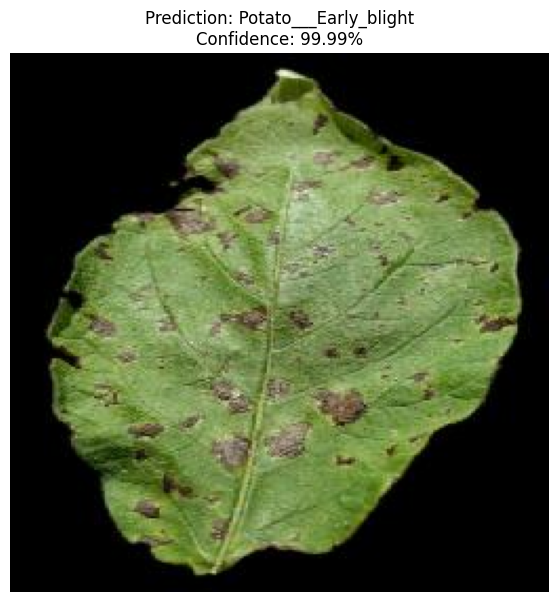

In [32]:
# CELL 32 — Predict a random test image

random_row = test_df.sample(
    1,
    random_state=random.randint(0, 100000)
).iloc[0]

image_path = random_row["image_path"]

image, predictions = predict_image(
    image_path,
    model,
    class_names,
    DEVICE,
    top_k=5
)

print("Actual:", random_row["class"])
print()

for i, result in enumerate(predictions, 1):
    print(
        f"{i}. {result['class']}: "
        f"{result['confidence']:.2%}"
    )

plt.figure(figsize=(7, 7))
plt.imshow(image)

plt.title(
    f"Prediction: {predictions[0]['class']}\n"
    f"Confidence: {predictions[0]['confidence']:.2%}"
)

plt.axis("off")
plt.show()

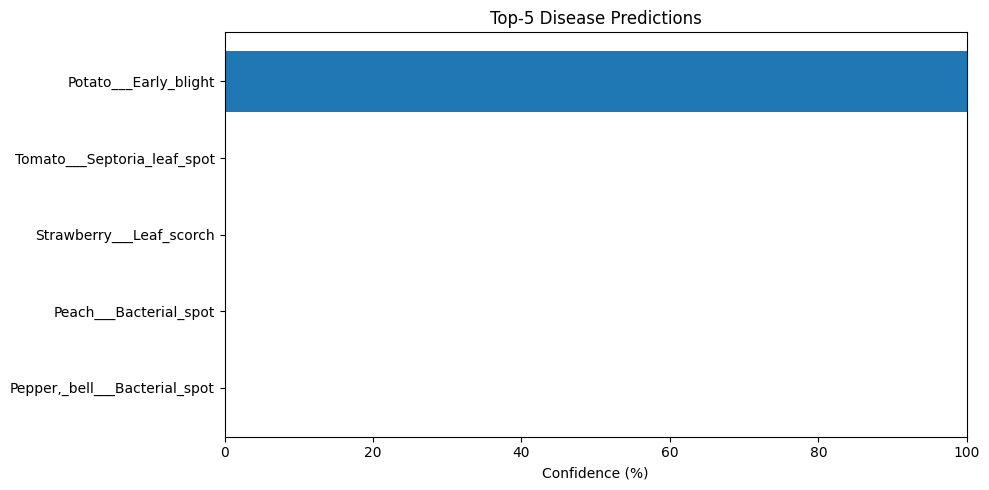

In [33]:
# CELL 33 — Prediction bar chart

labels = [
    x["class"] for x in predictions
]

values = [
    x["confidence"] * 100
    for x in predictions
]

plt.figure(figsize=(10, 5))

plt.barh(
    labels[::-1],
    values[::-1]
)

plt.xlabel("Confidence (%)")
plt.title("Top-5 Disease Predictions")

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## 12. Batch inference

This produces predictions and confidence values for a group of test images.

In [34]:
# CELL 34 — Batch prediction

def predict_dataframe(
    dataframe,
    model,
    class_names,
    device,
    max_images=100
):
    rows = []

    sample = dataframe.head(max_images)

    for _, row in tqdm(
        sample.iterrows(),
        total=len(sample),
        desc="Predicting"
    ):
        _, predictions = predict_image(
            row["image_path"],
            model,
            class_names,
            device,
            top_k=1
        )

        prediction = predictions[0]

        rows.append({
            "image_path": row["image_path"],
            "actual": row["class"],
            "predicted": prediction["class"],
            "confidence": prediction["confidence"]
        })

    return pd.DataFrame(rows)

batch_results = predict_dataframe(
    test_df.sample(
        min(100, len(test_df)),
        random_state=SEED
    ),
    model,
    class_names,
    DEVICE,
    max_images=100
)

batch_results.head()

Predicting:   0%|          | 0/100 [00:00<?, ?it/s]

,image_path,actual,predicted,confidence
0,/kaggle/input/datasets/abdallahalidev/plantvil...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.999889
1,/kaggle/input/datasets/abdallahalidev/plantvil...,Grape___healthy,Grape___healthy,0.999987
2,/kaggle/input/datasets/abdallahalidev/plantvil...,Tomato___Early_blight,Tomato___Early_blight,0.999999
3,/kaggle/input/datasets/abdallahalidev/plantvil...,Raspberry___healthy,Raspberry___healthy,0.999920
4,/kaggle/input/datasets/abdallahalidev/plantvil...,Orange___Haunglongbing_(Citrus_greening),Orange___Haunglongbing_(Citrus_greening),0.999933


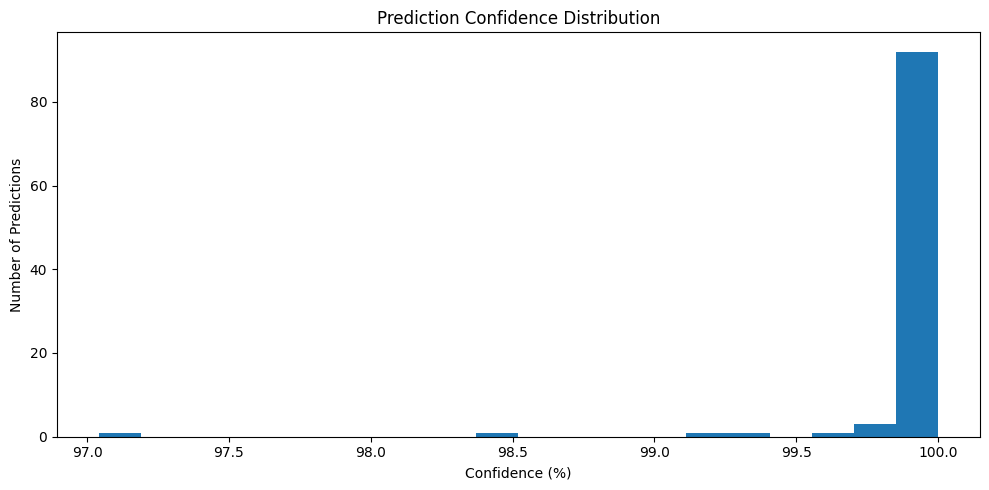

In [35]:
# CELL 35 — Confidence distribution

plt.figure(figsize=(10, 5))

plt.hist(
    batch_results["confidence"] * 100,
    bins=20
)

plt.xlabel("Confidence (%)")
plt.ylabel("Number of Predictions")
plt.title("Prediction Confidence Distribution")

plt.tight_layout()
plt.show()

## 13. Grad-CAM explainability

Grad-CAM shows which image regions influenced the classifier.

This is useful because a crop-health system should ideally focus on the leaf/plant rather than irrelevant background.

In [36]:
# CELL 36 — Grad-CAM imports

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("Grad-CAM ready.")

Grad-CAM ready.


In [37]:
# CELL 37 — Find EfficientNet target layer

target_layer = model.features[-1]

print(target_layer)

Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)


In [38]:
# CELL 38 — Grad-CAM visualization

def gradcam_image(
    image_path,
    model,
    target_layer,
    device
):
    original = Image.open(
        image_path
    ).convert("RGB")

    rgb = np.array(
        original.resize((IMG_SIZE, IMG_SIZE))
    ).astype(np.float32) / 255.0

    input_tensor = eval_transform(
        original
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(input_tensor)
        predicted_class = logits.argmax(dim=1).item()

    cam = GradCAM(
        model=model,
        target_layers=[target_layer]
    )

    targets = [
        ClassifierOutputTarget(predicted_class)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    visualization = show_cam_on_image(
        rgb,
        grayscale_cam,
        use_rgb=True
    )

    return (
        original,
        visualization,
        predicted_class
    )

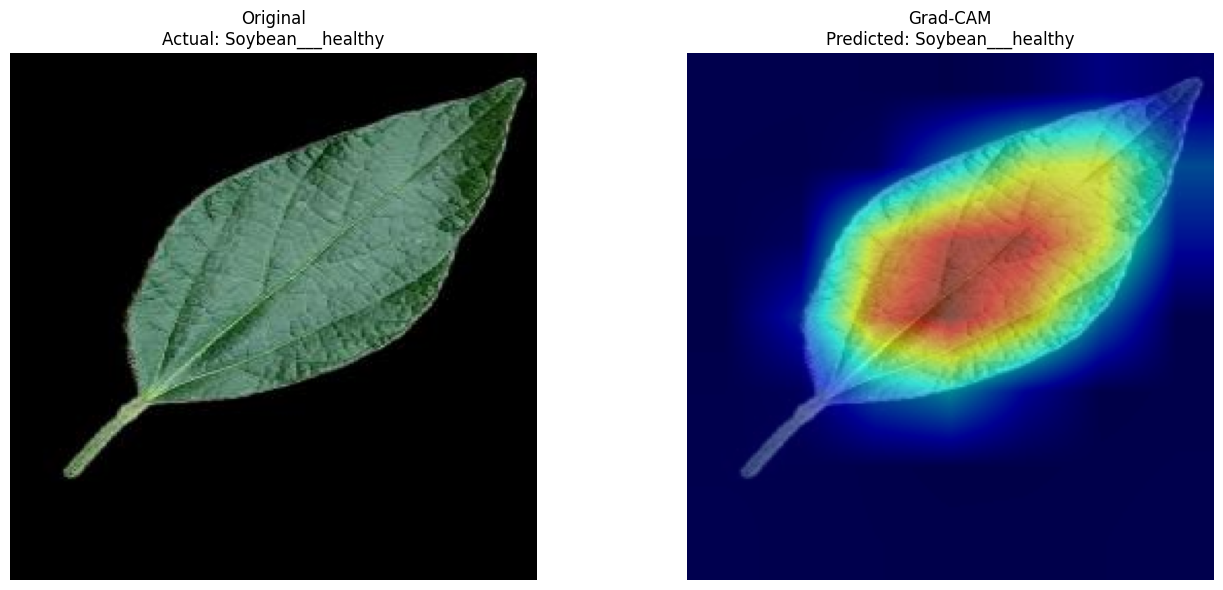

In [39]:
# CELL 39 — Run Grad-CAM

grad_row = test_df.sample(
    1,
    random_state=123
).iloc[0]

original, cam_image, predicted_index = gradcam_image(
    grad_row["image_path"],
    model,
    target_layer,
    DEVICE
)

predicted_name = class_names[predicted_index]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title(f"Original\nActual: {grad_row['class']}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title(f"Grad-CAM\nPredicted: {predicted_name}")
plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Indian crop dataset discovery

We do **not** blindly merge this dataset with PlantVillage because their disease labels may not be compatible.

First inspect the actual classes and structure. Then the dataset can be used as an external evaluation/extension set.

In [40]:
# CELL 40 — Find Indian crop dataset candidates

indian_candidates = []

for root, dirs, files in os.walk(INPUT_ROOT):
    lower = root.lower()

    keywords = [
        "crops-disease",
        "crop-disease",
        "crop disease",
        "indian",
        "rice",
        "wheat",
        "potato",
        "maize",
        "corn"
    ]

    if any(k in lower for k in keywords):
        indian_candidates.append(root)

print("Possible Indian crop locations:")
for p in indian_candidates[:100]:
    print("→", p)

Possible Indian crop locations:
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Potato___healthy
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Corn_(maize)___Northern_Leaf_Blight
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Potato___Late_blight
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Potato___Early_blight
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Corn_(maize)___Common_rust_
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Corn_(maize)___healthy
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/grayscale/Potato___healthy
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/grayscale/Corn_(maize)___Northern_Leaf_Blight
→ /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/grayscale/Corn_(m

In [41]:
# CELL 41 — Summarize candidate image counts

candidate_summary = []

for root in sorted(set(indian_candidates)):
    count = 0

    for subroot, _, files in os.walk(root):
        count += sum(
            f.endswith(IMAGE_EXTENSIONS)
            for f in files
        )

    if count > 0:
        candidate_summary.append({
            "path": root,
            "image_count": count
        })

pd.DataFrame(candidate_summary).sort_values(
    "image_count",
    ascending=False
).head(20)

,path,image_count
42,/kaggle/input/datasets/vishesh2395/crops-disea...,1278
43,/kaggle/input/datasets/vishesh2395/crops-disea...,1278
22,/kaggle/input/datasets/abdallahalidev/plantvil...,1192
15,/kaggle/input/datasets/abdallahalidev/plantvil...,1192
29,/kaggle/input/datasets/abdallahalidev/plantvil...,1192
36,/kaggle/input/datasets/abdallahalidev/plantvil...,1192
1,/kaggle/input/datasets/abdallahalidev/plantvil...,1192
8,/kaggle/input/datasets/abdallahalidev/plantvil...,1192
3,/kaggle/input/datasets/abdallahalidev/plantvil...,1162
24,/kaggle/input/datasets/abdallahalidev/plantvil...,1162


### Indian dataset note

At this point the notebook intentionally **does not claim cross-dataset accuracy**.

PlantVillage and the Indian dataset can have different:
- crop names
- disease names
- label definitions
- image distributions

A scientifically valid comparison requires mapping compatible classes or training/evaluating under a clearly defined protocol.

## 15. Optional PlantDoc / YOLO section

PlantDoc is useful for the **detection** part of the project.

The classification model above answers:

> What disease does this crop/leaf image belong to?

YOLO answers:

> Where are the relevant plants/disease regions in a field image?

This section detects whether a YOLO-format PlantDoc dataset is attached.

In [42]:
# CELL 42 — Find PlantDoc

plantdoc_candidates = []

for root, dirs, files in os.walk(INPUT_ROOT):
    if "plantdoc" in root.lower():
        plantdoc_candidates.append(root)

print("PlantDoc candidates:")

for p in plantdoc_candidates:
    print("→", p)

PlantDoc candidates:


In [43]:
# CELL 43 — Inspect PlantDoc files

if plantdoc_candidates:
    plantdoc_root = plantdoc_candidates[0]

    print("Using PlantDoc candidate:")
    print(plantdoc_root)

    for root, dirs, files in os.walk(plantdoc_root):
        level = root.replace(plantdoc_root, "").count(os.sep)

        if level <= 2:
            print(root)
else:
    print("PlantDoc not attached. Detection section will be skipped.")

PlantDoc not attached. Detection section will be skipped.


## 16. Optional YOLO training

If the attached PlantDoc dataset is YOLO-compatible, install Ultralytics and inspect its YAML file.

This is kept separate from the EfficientNet classifier because detection and classification are different tasks.

In [44]:
# CELL 44 — Install Ultralytics if PlantDoc exists

if plantdoc_candidates:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "ultralytics"
    ])

    from ultralytics import YOLO

    print("Ultralytics installed.")
else:
    print("Skipping Ultralytics because PlantDoc is not attached.")

Skipping Ultralytics because PlantDoc is not attached.


In [45]:
# CELL 45 — Find YOLO YAML files

yaml_files = []

for root, dirs, files in os.walk(INPUT_ROOT):
    for file in files:
        if file.endswith(".yaml") or file.endswith(".yml"):
            yaml_files.append(
                os.path.join(root, file)
            )

print("YAML files found:")

for p in yaml_files:
    print("→", p)

YAML files found:
→ /kaggle/input/datasets/andresmgs/plantdec/data.yaml


### Important

Do not run YOLO training until you have inspected the YAML path and class definitions.

The correct command depends on the exact PlantDoc Kaggle version and its YAML configuration.

## 17. Simple visual severity estimate

If you only have classification images, a true disease-segmentation percentage cannot be claimed.

The following optional heuristic estimates visually affected pixels from a leaf image. It is **not ground-truth disease severity** and should be described as an estimate.

For a production-quality severity metric, use a dataset with segmentation masks and train a segmentation model.

In [46]:
# CELL 46 — Heuristic severity estimator

import cv2

def estimate_visual_severity(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError("Could not read image.")

    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2HSV
    )

    # Approximate green vegetation mask.
    lower_green = np.array([25, 30, 20])
    upper_green = np.array([100, 255, 255])

    leaf_mask = cv2.inRange(
        hsv,
        lower_green,
        upper_green
    )

    # Approximate yellow/brown/damaged pixels.
    lower_damage = np.array([5, 30, 20])
    upper_damage = np.array([35, 255, 255])

    damage_mask = cv2.inRange(
        hsv,
        lower_damage,
        upper_damage
    )

    leaf_pixels = np.count_nonzero(leaf_mask)

    if leaf_pixels == 0:
        return None

    damaged_pixels = np.count_nonzero(
        damage_mask & leaf_mask
    )

    severity = (
        damaged_pixels /
        leaf_pixels
    ) * 100

    return float(
        np.clip(severity, 0, 100)
    )

In [47]:
# CELL 47 — Try visual severity estimate

severity_row = test_df.sample(
    1,
    random_state=456
).iloc[0]

severity = estimate_visual_severity(
    severity_row["image_path"]
)

print("Image:", severity_row["image_path"])
print("Actual class:", severity_row["class"])

if severity is None:
    print("Could not estimate severity from this image.")
else:
    print(
        f"Estimated visually affected area: "
        f"{severity:.2f}%"
    )

    if severity < 10:
        health = "LOW"
    elif severity < 30:
        health = "MODERATE"
    else:
        health = "HIGH"

    print("Estimated severity category:", health)

Image: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Orange___Haunglongbing_(Citrus_greening)/9ab3df99-006f-455b-a192-abb9c1ee8e1b___CREC_HLB 7357_final_masked.jpg
Actual class: Orange___Haunglongbing_(Citrus_greening)
Estimated visually affected area: 0.18%
Estimated severity category: LOW


## 18. Final end-to-end prediction report

This combines:
- disease prediction
- confidence
- optional visual severity estimate

For field-level deployment, the detector would be placed before this classifier.

In [48]:
# CELL 48 — Final crop health report

def crop_health_report(image_path):
    image, predictions = predict_image(
        image_path,
        model,
        class_names,
        DEVICE,
        top_k=5
    )

    top = predictions[0]

    severity = estimate_visual_severity(
        image_path
    )

    if severity is None:
        severity_text = "Unavailable"
        health_text = "Unknown"
    else:
        severity_text = f"{severity:.2f}%"

        if severity < 10:
            health_text = "LOW"
        elif severity < 30:
            health_text = "MODERATE"
        else:
            health_text = "HIGH"

    print("=" * 55)
    print("             CROP HEALTH REPORT")
    print("=" * 55)
    print(f"Prediction : {top['class']}")
    print(f"Confidence : {top['confidence']:.2%}")
    print(f"Severity   : {severity_text}")
    print(f"Health     : {health_text}")
    print("=" * 55)

    print("\nTop predictions:")

    for i, result in enumerate(predictions, 1):
        print(
            f"{i}. {result['class']:<45} "
            f"{result['confidence']:.2%}"
        )

    plt.figure(figsize=(8, 8))
    plt.imshow(image)

    plt.title(
        f"{top['class']}\n"
        f"Confidence: {top['confidence']:.2%}"
    )

    plt.axis("off")
    plt.show()

    return {
        "prediction": top["class"],
        "confidence": top["confidence"],
        "severity_estimate": severity,
        "health_category": health_text
    }

             CROP HEALTH REPORT
Prediction : Orange___Haunglongbing_(Citrus_greening)
Confidence : 100.00%
Severity   : 0.03%
Health     : LOW

Top predictions:
1. Orange___Haunglongbing_(Citrus_greening)      100.00%
2. Tomato___Spider_mites Two-spotted_spider_mite 0.00%
3. Pepper,_bell___Bacterial_spot                 0.00%
4. Pepper,_bell___healthy                        0.00%
5. Tomato___Late_blight                          0.00%


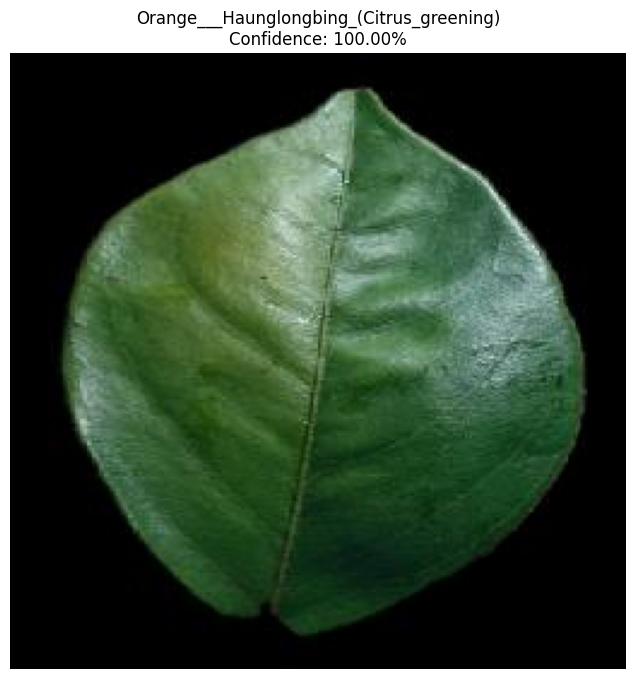

{'prediction': 'Orange___Haunglongbing_(Citrus_greening)',
 'confidence': 0.9999672174453735,
 'severity_estimate': 0.025553662691652473,
 'health_category': 'LOW'}

In [49]:
# CELL 49 — Run final report

final_row = test_df.sample(
    1,
    random_state=789
).iloc[0]

final_report = crop_health_report(
    final_row["image_path"]
)

final_report

## 19. Save final model and metadata

In [50]:
# CELL 50 — Save model, labels and results

FINAL_MODEL_PATH = "/kaggle/working/crop_health_monitoring_model.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "class_to_idx": class_to_idx,
        "img_size": IMG_SIZE,
        "test_accuracy": float(test_accuracy),
        "weighted_precision": float(precision),
        "weighted_recall": float(recall),
        "weighted_f1": float(f1)
    },
    FINAL_MODEL_PATH
)

results_summary = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],
    "Score": [
        test_accuracy,
        precision,
        recall,
        f1
    ]
})

results_summary.to_csv(
    "/kaggle/working/crop_health_metrics.csv",
    index=False
)

print("Saved:")
print(FINAL_MODEL_PATH)
print("/kaggle/working/crop_health_metrics.csv")

Saved:
/kaggle/working/crop_health_monitoring_model.pth
/kaggle/working/crop_health_metrics.csv


In [51]:
# CELL 51 — Final project summary

print("=" * 60)
print("           CROP HEALTH MONITORING PROJECT")
print("=" * 60)

print(f"Dataset images:       {len(df):,}")
print(f"Disease classes:      {len(class_names)}")
print(f"Training images:      {len(train_df):,}")
print(f"Validation images:    {len(val_df):,}")
print(f"Test images:          {len(test_df):,}")

print("\nMODEL")
print("Architecture:         EfficientNet-B0")
print("Input size:           224 × 224")
print("Transfer learning:    ImageNet")

print("\nTEST PERFORMANCE")
print(f"Accuracy:             {test_accuracy:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"Recall:               {recall:.4f}")
print(f"F1:                   {f1:.4f}")

print("\nFEATURES")
print("✓ Disease classification")
print("✓ Confidence scores")
print("✓ Top-5 predictions")
print("✓ Confusion matrix")
print("✓ Per-class metrics")
print("✓ Grad-CAM explainability")
print("✓ Indian dataset inspection")
print("✓ PlantDoc/YOLO support")
print("✓ Visual severity estimate")
print("✓ Model checkpointing")

print("=" * 60)

           CROP HEALTH MONITORING PROJECT
Dataset images:       54,306
Disease classes:      38
Training images:      43,444
Validation images:    5,431
Test images:          5,431

MODEL
Architecture:         EfficientNet-B0
Input size:           224 × 224
Transfer learning:    ImageNet

TEST PERFORMANCE
Accuracy:             0.9954
Precision:            0.9955
Recall:               0.9954
F1:                   0.9954

FEATURES
✓ Disease classification
✓ Confidence scores
✓ Top-5 predictions
✓ Confusion matrix
✓ Per-class metrics
✓ Grad-CAM explainability
✓ Indian dataset inspection
✓ PlantDoc/YOLO support
✓ Visual severity estimate
✓ Model checkpointing


In [52]:
import os

files = [
    "/kaggle/working/crop_health_monitoring_model.pth",
    "/kaggle/working/crop_health_metrics.csv",
]

for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024 * 1024)
        print(f"✓ {f} — {size:.2f} MB")
    else:
        print(f"✗ Missing: {f}")

✓ /kaggle/working/crop_health_monitoring_model.pth — 15.77 MB
✓ /kaggle/working/crop_health_metrics.csv — 0.00 MB


In [53]:
print("========== FINAL RESULTS ==========")
print(f"Test Accuracy:  {test_accuracy:.4%}")
print(f"Precision:      {precision:.4%}")
print(f"Recall:         {recall:.4%}")
print(f"F1 Score:       {f1:.4%}")
print(f"Classes:        {len(class_names)}")
print(f"Train Images:   {len(train_df):,}")
print(f"Test Images:    {len(test_df):,}")

========== FINAL RESULTS ==========
Test Accuracy:  99.5397%
Precision:      99.5455%
Recall:         99.5397%
F1 Score:       99.5390%
Classes:        38
Train Images:   43,444
Test Images:    5,431


             CROP HEALTH REPORT
Prediction : Tomato___Late_blight
Confidence : 99.99%
Severity   : 2.69%
Health     : LOW

Top predictions:
1. Tomato___Late_blight                          99.99%
2. Potato___Late_blight                          0.01%
3. Tomato___Early_blight                         0.00%
4. Tomato___Septoria_leaf_spot                   0.00%
5. Tomato___healthy                              0.00%


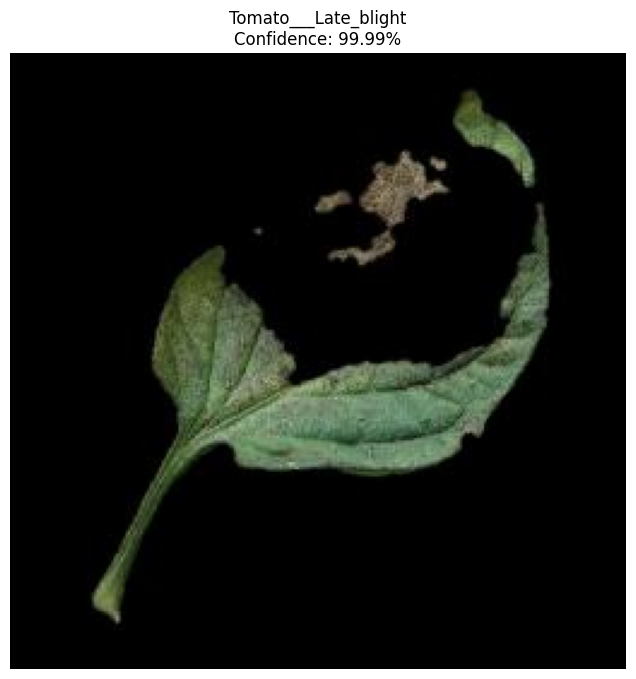

In [54]:
final_row = test_df.sample(
    1,
    random_state=999
).iloc[0]

final_report = crop_health_report(
    final_row["image_path"]
)